# {{ notebook_title }}


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

root = Path.cwd()
while not (root / 'pyproject.toml').exists() and root != root.parent:
    root = root.parent
stats_path = Path({{ statistics_path }})
if not stats_path.is_absolute():
    stats_path = root / stats_path
stats = json.loads(stats_path.read_text())
components = np.asarray(stats['component'])
cumulative_variance = np.asarray(stats['cumulative_explained_variance_ratio'])
sns.set_theme(style='whitegrid')

In [2]:
thresholds = (0.90, 0.95, 0.99)
for threshold in thresholds:
    reached = np.flatnonzero(cumulative_variance >= threshold)
    result = int(components[reached[0]]) if reached.size else f'>{components[-1]}'
    print(f'{threshold:.0%}: {result} components')

90%: 17 components
95%: 48 components
99%: 321 components


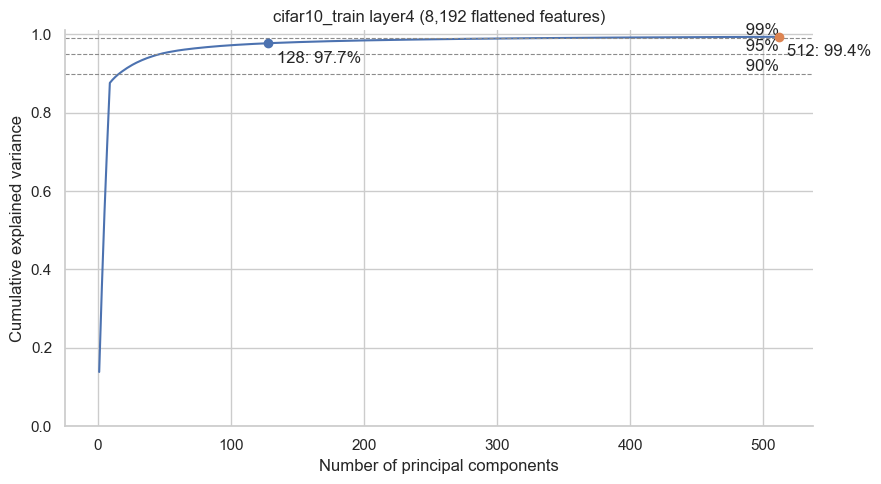

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(x=components, y=cumulative_variance, ax=ax)
for threshold in thresholds:
    ax.axhline(threshold, color='0.55', linestyle='--', linewidth=0.8)
    ax.text(components[-1], threshold, f' {threshold:.0%}', va='bottom', ha='right')
for candidate in (128, 512):
    if candidate <= components[-1]:
        variance = cumulative_variance[candidate - 1]
        ax.scatter(candidate, variance, zorder=3)
        ax.annotate(f'{candidate}: {variance:.1%}', (candidate, variance), xytext=(6, -14), textcoords='offset points')
ax.set(xlabel='Number of principal components', ylabel='Cumulative explained variance', ylim=(0, 1.01))
ax.set_title(f"{stats['dataset']} {stats['layer']} ({stats['n_features']:,} flattened features)")
sns.despine()
fig.tight_layout()

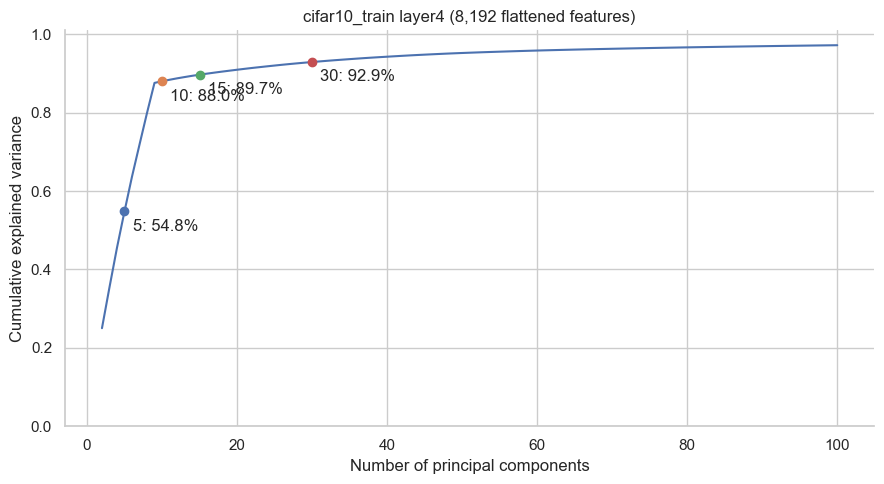

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

mask = components < 100
sns.lineplot(x=components[mask], y=cumulative_variance[mask], ax=ax)

for candidate in (5, 10, 30):
    if candidate <= components[-1]:
        variance = cumulative_variance[candidate - 1]
        ax.scatter(candidate, variance, zorder=3)
        ax.annotate(f'{candidate}: {variance:.1%}', (candidate, variance), xytext=(6, -14), textcoords='offset points')
ax.set(xlabel='Number of principal components', ylabel='Cumulative explained variance', ylim=(0, 1.01))
ax.set_title(f"{stats['dataset']} {stats['layer']} ({stats['n_features']:,} flattened features)")
sns.despine()
fig.tight_layout()